# S&P 500 Volatility Forecasting: Leakage-Free Evaluation

This is the repository's canonical, reproducible one-step-ahead evaluation of daily conditional-variance forecasts against intraday realized variance (RV). Legacy notebooks remain available for historical reference but are not the source of the current model conclusion.

## Scope and assumptions

- **Underlying:** S&P 500 index (SPX). The canonical datasets use SPX names to avoid the legacy SPY filename ambiguity.
- **Train/test split:** train through 2024-06-28; test from 2024-07-01 through 2024-12-31. The notebook asserts that the two samples have no overlapping dates.
- **Target:** $RV_t = \sum_{j=1}^{M_t} r_{t,j}^2$, using intraday 30-minute close-to-close log returns. This is intraday RV only: it excludes overnight close-to-open variation.
- **Forecast timing:** each forecast for date $t$ may use returns through $t-1$ only.
- **Models:** calibrated EWMA, skew-t EGARCH(1,1), and skew-t GJR-GARCH(1,1). FIGARCH is intentionally excluded from the base comparison because the earlier in-sample long-memory estimate was weak; it can be added later as a separately justified extension.

## Reproducibility

Run this notebook from `code/`. Required packages include `pandas`, `numpy`, `scipy`, `statsmodels`, `matplotlib`, `openpyxl`, and `arch`. If `arch` is unavailable, install it in the selected kernel before running the model cells (for example, `%pip install arch`). Record the resulting package versions with the next cell.

In [1]:
from pathlib import Path
import importlib.metadata as metadata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import statsmodels.api as sm
from scipy.optimize import minimize_scalar
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

try:
    from arch import arch_model
    ARCH_AVAILABLE = True
except ModuleNotFoundError:
    ARCH_AVAILABLE = False
    print('arch: NOT INSTALLED — run `%pip install arch` in this kernel before the forecast cells.')

for package in ['numpy', 'pandas', 'scipy', 'statsmodels']:
    print(f'{package}: {metadata.version(package)}')
if ARCH_AVAILABLE:
    print(f'arch: {metadata.version("arch")}')

numpy: 2.5.3
pandas: 3.0.6
scipy: 1.18.1
statsmodels: 0.15.0
arch: 8.0.0


In [2]:
# Resolve paths whether the kernel starts in code/ or the repository root.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / 'data').exists(), 'Run from the repository root or code/ directory.'

TRAIN_PATH = PROJECT_ROOT / 'data/processed/canonical/spx_close_returns_train_2023-01-04_to_2024-06-28.csv'
TEST_PATH = PROJECT_ROOT / 'data/processed/canonical/spx_close_returns_test_2024-07-01_to_2024-12-31.csv'
RV_PATH = PROJECT_ROOT / 'data/processed/canonical/spx_realized_variance_2024-07-01_to_2024-12-31.csv'

train = pd.read_csv(TRAIN_PATH, parse_dates=['Date']).sort_values('Date').set_index('Date')
test = pd.read_csv(TEST_PATH, parse_dates=['Date']).sort_values('Date').set_index('Date')

assert train.index.is_unique and test.index.is_unique
assert train.index.max() < test.index.min(), 'Train must end before test begins.'
assert train.index.intersection(test.index).empty, 'Train/test date overlap detected.'
assert train['log_return'].notna().all() and test['log_return'].notna().all()

print(f'Train: {train.index.min():%Y-%m-%d} to {train.index.max():%Y-%m-%d} ({len(train)} days)')
print(f'Test:  {test.index.min():%Y-%m-%d} to {test.index.max():%Y-%m-%d} ({len(test)} days)')

Train: 2023-01-04 to 2024-06-28 (373 days)
Test:  2024-07-01 to 2024-12-31 (128 days)


## Load the versioned realized-variance target

The canonical RV dataset is deterministically rebuilt by `scripts/build_canonical_rv_data.py` from the versioned raw 30-minute intraday file. The first observation of each trading day has no intraday predecessor and is not counted as a return. Early closes remain in the sample but their lower interval count is disclosed.

In [3]:
rv = pd.read_csv(RV_PATH, parse_dates=['Date']).sort_values('Date').set_index('Date')
required_columns = {'interval_returns', 'realized_variance', 'realized_volatility'}
assert required_columns.issubset(rv.columns), f'Missing columns: {required_columns - set(rv.columns)}'
assert rv.index.is_unique and rv['realized_variance'].gt(0).all()

print(rv[['interval_returns', 'realized_variance']].describe())
print('Short-session days:', int((rv['interval_returns'] < rv['interval_returns'].max()).sum()))

       interval_returns  realized_variance
count        128.000000         128.000000
mean          12.882812           0.000037
std            0.759414           0.000044
min            8.000000           0.000003
25%           13.000000           0.000011
50%           13.000000           0.000021
75%           13.000000           0.000043
max           13.000000           0.000286
Short-session days: 3


In [4]:
# Every evaluation date must have the same-day intraday RV target.
evaluation = test[['log_return']].join(rv[['realized_variance', 'interval_returns']], how='left')
assert len(evaluation) == len(test)
assert evaluation['realized_variance'].notna().all(), 'Missing RV target for one or more test dates.'
assert evaluation['realized_variance'].gt(0).all()

evaluation.head()

,log_return,realized_variance,interval_returns
Date,,,
2024-07-01,0.002672,0.000012,13
2024-07-02,0.006176,0.000009,13
2024-07-03,0.005072,0.000005,8
2024-07-05,0.005434,0.000005,13
2024-07-08,0.001016,0.000006,13


## Forecast functions

Returns are multiplied by 100 during estimation, so conditional variances are divided by $100^2$ before comparison with RV. EWMA $\lambda$ is fitted by Gaussian quasi-likelihood on the training sample only.

In [5]:
if not ARCH_AVAILABLE:
    raise ModuleNotFoundError('Install `arch` with `%pip install arch`, then restart the kernel and rerun.')

train_returns_pct = 100.0 * train['log_return'].to_numpy()
test_returns_pct = 100.0 * test['log_return'].to_numpy()

def ewma_next_variance(returns_pct, lam):
    """Forecast variance after the final return in returns_pct."""
    variance = np.var(returns_pct, ddof=1)
    for value in returns_pct:
        variance = lam * variance + (1.0 - lam) * value**2
    return max(variance, 1e-12)

def ewma_negative_loglikelihood(lam, returns_pct):
    variance = np.var(returns_pct, ddof=1)
    losses = []
    for value in returns_pct[1:]:
        variance = lam * variance + (1.0 - lam) * returns_pct[len(losses)]**2
        losses.append(0.5 * (np.log(variance) + value**2 / variance))
    return float(np.sum(losses))

lambda_fit = minimize_scalar(
    ewma_negative_loglikelihood, bounds=(0.80, 0.999), args=(train_returns_pct,), method='bounded'
)
assert lambda_fit.success
EWMA_LAMBDA = float(lambda_fit.x)
print(f'Calibrated EWMA lambda: {EWMA_LAMBDA:.6f}')

MODEL_SPECS = {
    'EGARCH(1,1)-skewt': dict(vol='EGARCH', p=1, o=1, q=1, dist='skewt'),
    'GJR-GARCH(1,1)-skewt': dict(vol='GARCH', p=1, o=1, q=1, dist='skewt'),
}

def arch_next_variance(returns_pct, spec):
    model = arch_model(returns_pct, mean='Constant', **spec)
    fitted = model.fit(disp='off', show_warning=False)
    forecast = fitted.forecast(horizon=1, reindex=False)
    return float(forecast.variance.iloc[-1, 0]), fitted

Calibrated EWMA lambda: 0.958820


## Expanding-window one-step-ahead forecasts

The assertion inside the loop is the anti-leakage control: for test date $t$, the maximum observable return date must be strictly earlier than $t$. This cell refits two ARCH models 128 times and may take several minutes.

In [6]:
forecast_rows = []
for position, forecast_date in enumerate(test.index):
    history_dates = train.index.append(test.index[:position])
    assert history_dates.max() < forecast_date
    history_pct = np.concatenate([train_returns_pct, test_returns_pct[:position]])

    row = {
        'Date': forecast_date,
        'history_end': history_dates.max(),
        'EWMA': ewma_next_variance(history_pct, EWMA_LAMBDA) / 10_000.0,
    }
    for model_name, spec in MODEL_SPECS.items():
        variance_pct2, _ = arch_next_variance(history_pct, spec)
        row[model_name] = variance_pct2 / 10_000.0
    forecast_rows.append(row)

forecasts = pd.DataFrame(forecast_rows).set_index('Date')
assert (forecasts['history_end'] < forecasts.index).all()
forecast_columns = list(MODEL_SPECS) + ['EWMA']
evaluation = evaluation.join(forecasts[forecast_columns], how='inner')
assert len(evaluation) == len(test)
evaluation.head()

,log_return,realized_variance,interval_returns,"EGARCH(1,1)-skewt","GJR-GARCH(1,1)-skewt",EWMA
Date,,,,,,
2024-07-01,0.002672,0.000012,13,0.000038,0.000032,0.000030
2024-07-02,0.006176,0.000009,13,0.000036,0.000030,0.000029
2024-07-03,0.005072,0.000005,8,0.000033,0.000030,0.000030
2024-07-05,0.005434,0.000005,13,0.000030,0.000029,0.000029
2024-07-08,0.001016,0.000006,13,0.000028,0.000028,0.000029


## Out-of-sample evaluation

QLIKE is the primary loss because it is robust to noise in realized-variance proxies. MSE, RMSE, and MAE are supplementary. The Diebold--Mariano-style comparison estimates the mean QLIKE-loss difference with HAC standard errors; a positive difference means the row model has higher loss than the column model.

In [7]:
def qlike(actual, forecast):
    forecast = np.maximum(np.asarray(forecast), 1e-16)
    return np.log(forecast) + np.asarray(actual) / forecast

actual_rv = evaluation['realized_variance'].to_numpy()
metrics = []
for model_name in forecast_columns:
    predicted = evaluation[model_name].to_numpy()
    metrics.append({
        'model': model_name,
        'QLIKE': qlike(actual_rv, predicted).mean(),
        'MSE': np.mean((actual_rv - predicted) ** 2),
        'RMSE': np.sqrt(np.mean((actual_rv - predicted) ** 2)),
        'MAE': np.mean(np.abs(actual_rv - predicted)),
    })
metrics_table = pd.DataFrame(metrics).sort_values('QLIKE').reset_index(drop=True)
metrics_table

,model,QLIKE,MSE,RMSE,MAE
0,"EGARCH(1,1)-skewt",-9.188136,2.468949e-09,0.000050,0.000040
1,"GJR-GARCH(1,1)-skewt",-9.123745,4.300015e-09,0.000066,0.000050
2,EWMA,-9.067274,3.544167e-09,0.000060,0.000049


In [8]:
def dm_qlike(model_a, model_b, maxlags=None):
    if maxlags is None:
        maxlags = int(np.sqrt(len(evaluation)))
    loss_difference = qlike(actual_rv, evaluation[model_a]) - qlike(actual_rv, evaluation[model_b])
    fit = sm.OLS(loss_difference, np.ones(len(loss_difference))).fit(
        cov_type='HAC', cov_kwds={'maxlags': maxlags}
    )
    return fit.params[0], fit.tvalues[0], fit.pvalues[0]

dm_rows = []
for model_a in forecast_columns:
    for model_b in forecast_columns:
        if model_a >= model_b:
            continue
        mean_difference, statistic, pvalue = dm_qlike(model_a, model_b)
        dm_rows.append({
            'model_a': model_a, 'model_b': model_b,
            'mean_QLIKE_a_minus_b': mean_difference,
            'HAC_t_stat': statistic, 'p_value': pvalue,
        })
pd.DataFrame(dm_rows).sort_values('p_value')

,model_a,model_b,mean_QLIKE_a_minus_b,HAC_t_stat,p_value
1,"EGARCH(1,1)-skewt",EWMA,-0.120863,-3.316707,0.000911
0,"EGARCH(1,1)-skewt","GJR-GARCH(1,1)-skewt",-0.064392,-2.195820,0.028105
2,EWMA,"GJR-GARCH(1,1)-skewt",0.056471,1.486915,0.137037


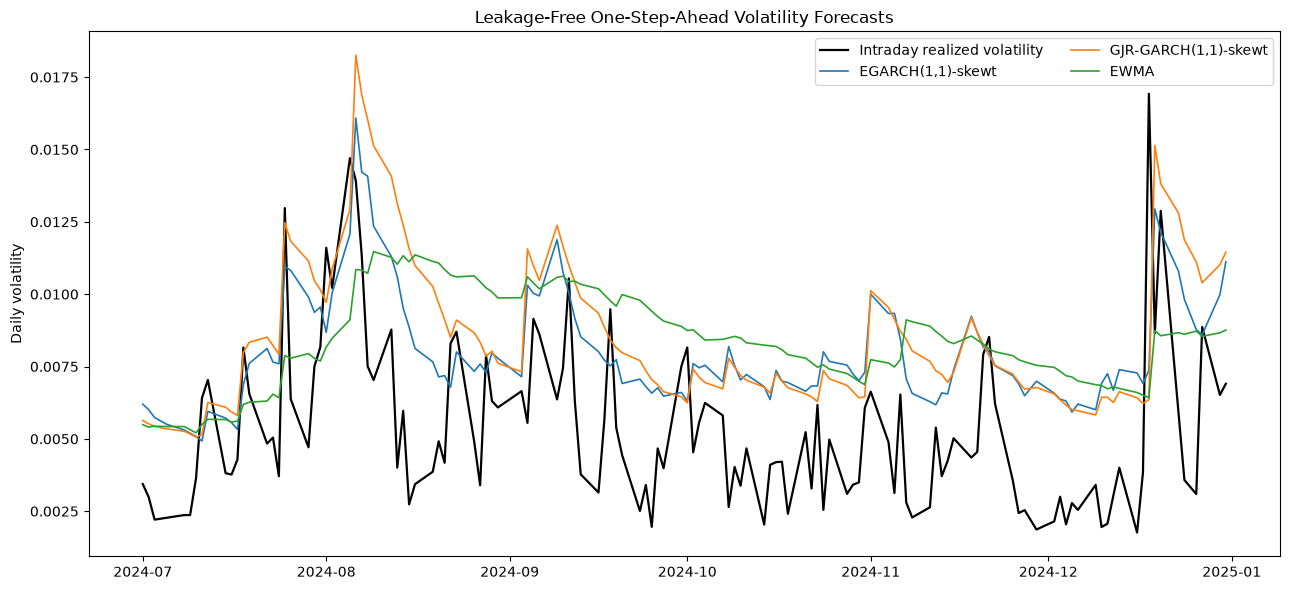

In [9]:
plt.figure(figsize=(13, 6))
plt.plot(evaluation.index, np.sqrt(evaluation['realized_variance']), color='black', lw=1.6, label='Intraday realized volatility')
for model_name in forecast_columns:
    plt.plot(evaluation.index, np.sqrt(evaluation[model_name]), lw=1.2, label=model_name)
plt.title('Leakage-Free One-Step-Ahead Volatility Forecasts')
plt.ylabel('Daily volatility')
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

## In-sample diagnostics of ARCH candidates

These tests assess the original training-period fit only; they do not replace out-of-sample forecast evaluation. They test serial dependence in standardized residuals and squared standardized residuals, plus remaining ARCH effects.

In [10]:
diagnostics = []
for model_name, spec in MODEL_SPECS.items():
    _, fitted = arch_next_variance(train_returns_pct, spec)
    standardized_residuals = pd.Series(fitted.std_resid).dropna()
    lb_residual = acorr_ljungbox(standardized_residuals, lags=[10, 20], return_df=True)
    lb_squared = acorr_ljungbox(standardized_residuals**2, lags=[10, 20], return_df=True)
    _, arch_pvalue, _, _ = het_arch(standardized_residuals, nlags=10)
    diagnostics.append({
        'model': model_name,
        'BIC_train': fitted.bic,
        'ARCH_LM_pvalue_lag10': arch_pvalue,
        'LB_resid_pvalue_lag10': lb_residual.loc[10, 'lb_pvalue'],
        'LB_resid_pvalue_lag20': lb_residual.loc[20, 'lb_pvalue'],
        'LB_sq_resid_pvalue_lag10': lb_squared.loc[10, 'lb_pvalue'],
        'LB_sq_resid_pvalue_lag20': lb_squared.loc[20, 'lb_pvalue'],
    })
diagnostics_table = pd.DataFrame(diagnostics).set_index('model')
diagnostics_table

/private/tmp/ts-volatility-canonical-main/.venv/lib/python3.12/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(
/private/tmp/ts-volatility-canonical-main/.venv/lib/python3.12/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


,BIC_train,ARCH_LM_pvalue_lag10,LB_resid_pvalue_lag10,LB_resid_pvalue_lag20,LB_sq_resid_pvalue_lag10,LB_sq_resid_pvalue_lag20
model,,,,,,
"EGARCH(1,1)-skewt",882.574577,0.212688,0.282123,0.071668,0.223715,0.368171
"GJR-GARCH(1,1)-skewt",884.488638,0.110508,0.377287,0.094817,0.085011,0.087327


## Decision rule and limitations

Choose the model with the lowest QLIKE only if its relevant Diebold--Mariano comparison does not contradict the claimed advantage. Treat close, statistically insignificant losses as model uncertainty rather than a winner-takes-all result.

This study is an historical research exercise, not a bank quote or a trading signal. The RV target excludes overnight variation and may be noisier on early-close days. A future extension should evaluate an aligned S&P 500 total daily variance target, add VaR/ES backtests, and compare a HAR-RV specification.